# IPF fertility visualisation, August 2025

In [18]:
from minos.fertility_utils import *
from minos.fertility_ipf import *
import matplotlib as mpl
from matplotlib import pyplot as plt
import seaborn as sns

# HR 20/08/25 Get path to N latest dataset by config
def get_latest_by_config(config,
                         n=1,
                         intervention=None,
                         ):

    if intervention:
        intervention_mode = intervention  # Placeholder - can replace with dict lookup later if necessary
    else:
        intervention_mode = 'baseline'

    modepath = os.path.join(OUTPUT_DEFAULT, config, intervention_mode)
    latest = sorted(os.listdir(modepath))[-n:]
    fullpath = [os.path.join(modepath, p) for p in latest]
    return fullpath


# Cut off first year, which isn't acted on in simulation
START_YEAR = 2020

In [2]:
# Get sim data
path_noparity = get_latest_by_config('gb_scaled_noparity_ipf', n=1)[-1]
files_noparity = {int(f.split('.')[0]): os.path.join(path_noparity, f) for f in os.listdir(path_noparity) if f.endswith('csv')}
path_parity = get_latest_by_config('gb_scaled_parity_ipf', n=1)[-1]
files_parity = {int(f.split('.')[0]): os.path.join(path_parity, f) for f in os.listdir(path_parity) if f.endswith('csv')}

# 1. Get basic TFR for whole populations (i.e. no disaggregation by age or ethnicity)
tfr_np = {y: get_tfr(pd.read_csv(file, low_memory=False)) for y, file in files_noparity.items()}
tfr_p = {y: get_tfr(pd.read_csv(file, low_memory=False)) for y, file in files_parity.items()}

In [ ]:
# 2. Get TFR by ethnic group
tfr_grouped_np = {}
tfr_grouped_p = {}

for year in files_noparity:
    data_p = pd.read_csv(files_parity[year], low_memory=False)
    data_np = pd.read_csv(files_noparity[year], low_memory=False)

    apply_ethnicity_group(data_p)
    apply_ethnicity_group(data_np)
    
    tfr_p = get_tfr(data_p)
    tfr_np = get_tfr(data_np)

    tfr_grouped_p[year] = data_p.groupby('eth_group').apply(lambda x: get_tfr(x))
    tfr_grouped_np[year] = data_np.groupby('eth_group').apply(lambda x: get_tfr(x))

tfr_eth_np = pd.DataFrame(tfr_grouped_np).T.sort_index()
tfr_eth_np = tfr_eth_np[tfr_eth_np.index >= START_YEAR]
tfr_eth_p = pd.DataFrame(tfr_grouped_p).T.sort_index()
tfr_eth_p = tfr_eth_p[tfr_eth_p.index >= START_YEAR]

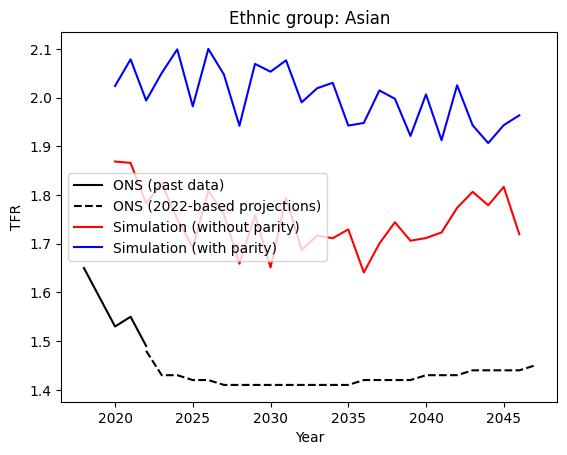

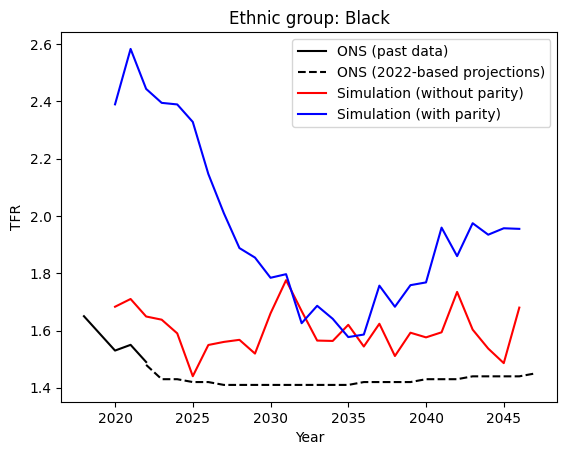

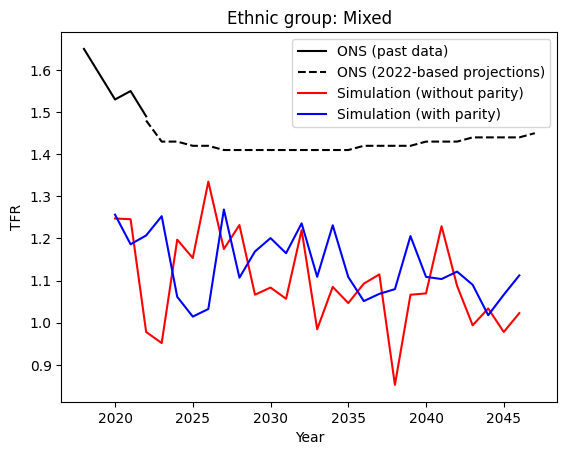

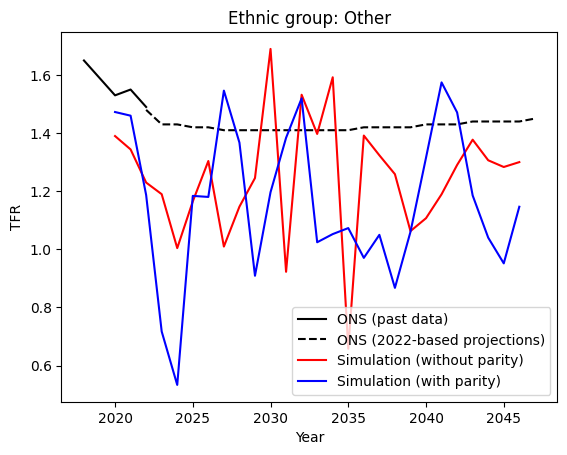

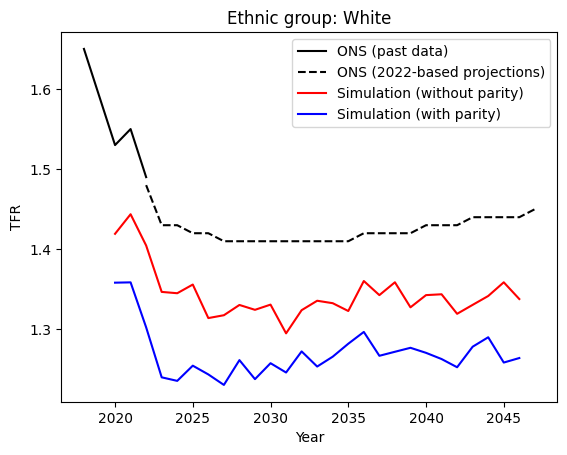

In [22]:
# 3. Compare TFR by ethnic group
tfr_past = get_fertility_reference_data()['tfr_ref'][[2018, 2019, 2020, 2021, 2022]].to_dict()
tfr_future = get_tfr_projections().loc[2022:].to_dict()['tfr']

for i, eth in enumerate(tfr_eth_np.columns):
    legend_labels = []
    plt.figure()
    plt.plot(*zip(*tfr_past.items()), color='black')
    plt.plot(*zip(*tfr_future.items()), color='black', linestyle='--')
    legend_labels.extend(['ONS (past data)', 'ONS (2022-based projections)'])
    
    plt.plot(tfr_eth_np[eth], color='red')
    legend_labels.append('Simulation (without parity)')
    plt.plot(tfr_eth_p[eth], color='blue')
    legend_labels.append('Simulation (with parity)')

    plt.title('Ethnic group: ' + eth.title())
    plt.xlabel('Year')
    plt.ylabel('TFR')
    plt.legend(labels=legend_labels)
    plt.show()

In [ ]:
# 4. Get ASFR by five-year age bracket and plot on its own
asfr_np = {y: get_asfr(pd.read_csv(file, low_memory=False), bins=BINS_DEFAULT, interval=INTERVAL_DEFAULT) for y, file in files_noparity.items()}
asfr_p = {y: get_asfr(pd.read_csv(file, low_memory=False), bins=BINS_DEFAULT, interval=INTERVAL_DEFAULT) for y, file in files_parity.items()}

asfr_np = pd.DataFrame(asfr_np).T.sort_index()
asfr_np = asfr_np[asfr_np.index >= START_YEAR]
asfr_p = pd.DataFrame(asfr_p).T.sort_index()
asfr_p = asfr_p[asfr_p.index >= START_YEAR]

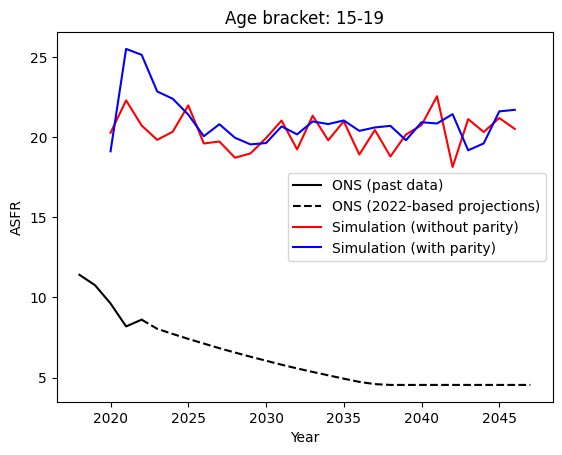

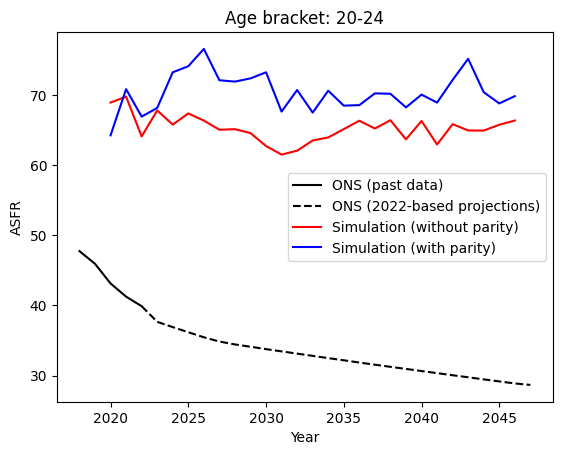

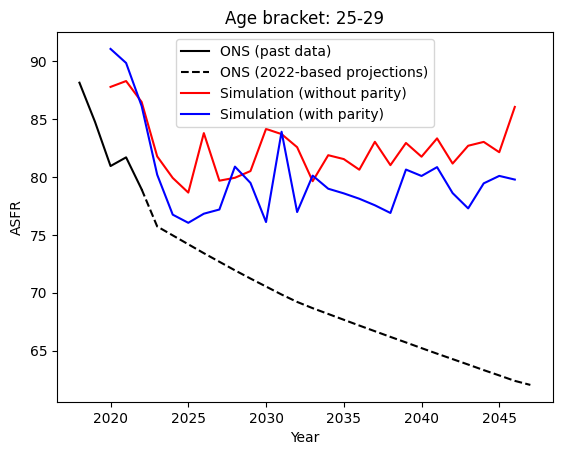

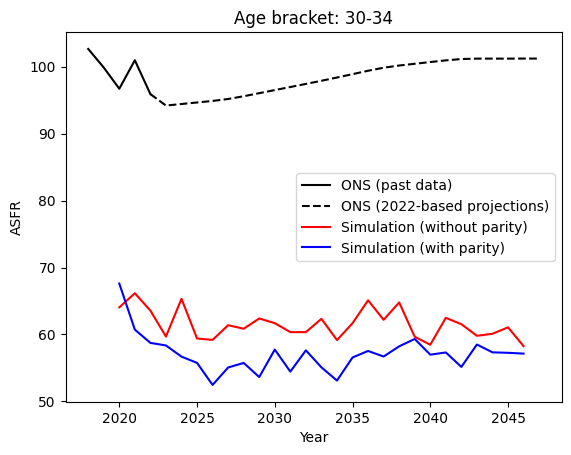

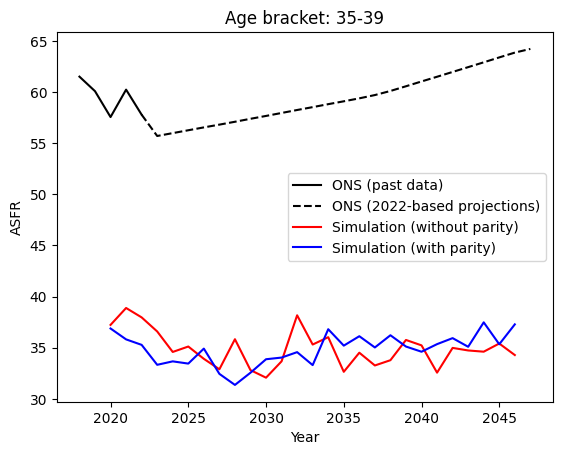

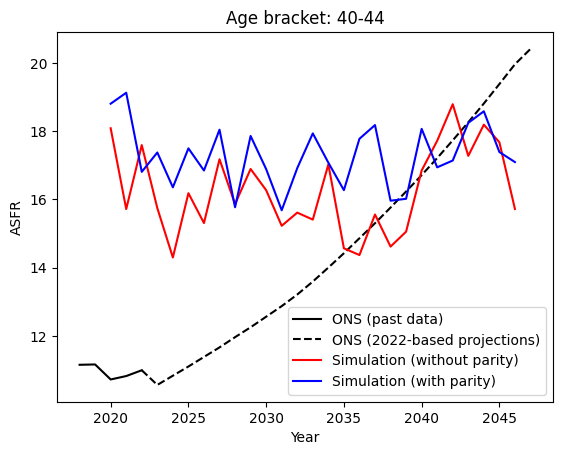

In [40]:
# Get reference data
asfr_ref_all = get_asfr_projections()
asfr_ref_all.columns = [int(el.split(' ')[0]) for el in asfr_ref_all.columns]
asfr_past = asfr_ref_all.loc[asfr_ref_all.index.isin([2018, 2019, 2020, 2021, 2022])].to_dict()
asfr_future = asfr_ref_all.loc[asfr_ref_all.index >= 2022].to_dict()

for age_bracket in asfr_past:
    legend_labels = []
    plt.figure()
    ref_past = asfr_past[age_bracket]
    ref_future = asfr_future[age_bracket]
    plt.plot(*zip(*ref_past.items()), color='black')
    plt.plot(*zip(*ref_future.items()), color='black', linestyle='--')
    legend_labels.extend(['ONS (past data)', 'ONS (2022-based projections)'])

    plt.plot(asfr_np[age_bracket], color='red')
    legend_labels.append('Simulation (without parity)')
    plt.plot(asfr_p[age_bracket], color='blue')
    legend_labels.append('Simulation (with parity)')
    
    plt.title('Age bracket: ' + str(age_bracket) + '-' + str(age_bracket + 4))
    plt.xlabel('Year')
    plt.ylabel('ASFR')
    plt.legend(labels=legend_labels)
    plt.show()

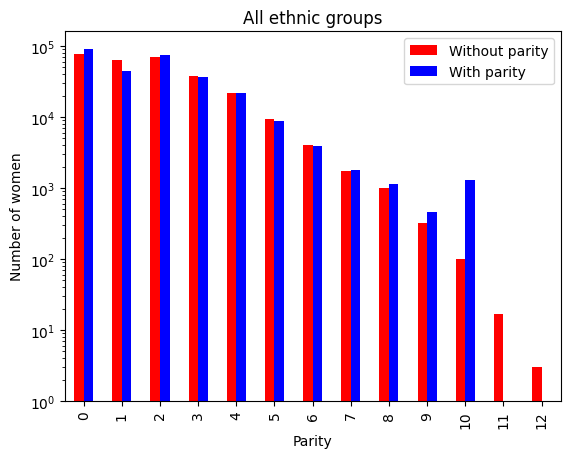

In [13]:
# 5. Show children per women at end of simulation
def get_nkids_ind_distribution(data_raw):
    data = data_raw.loc[(data_raw['alive'] == 'alive') & (data_raw['sex'] == 'Female')]
    result = data['nkids_ind'].value_counts(dropna=False).sort_index()    
    return result
    
year_end = max(files_parity)
enddata_p = pd.read_csv(files_parity[year_end], low_memory=False)
enddata_np = pd.read_csv(files_noparity[year_end], low_memory=False)

# No subgroups - whole populations
kids_p = get_nkids_ind_distribution(enddata_p)
kids_np = get_nkids_ind_distribution(enddata_np)
kids_all = pd.DataFrame([kids_np, kids_p]).T
kids_all.columns = ['Without parity', 'With parity']
kids1 = kids_all.plot.bar(title='All ethnic groups', xlabel='Parity', ylabel='Number of women', color=['red', 'blue'], log=True)   

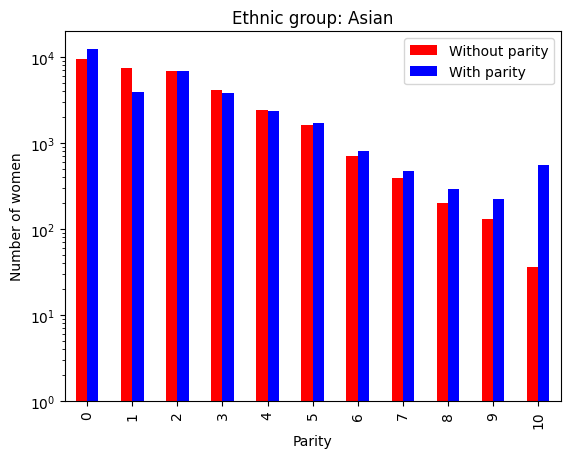

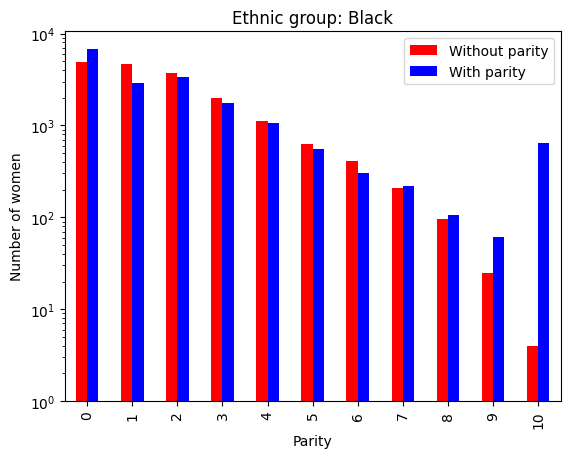

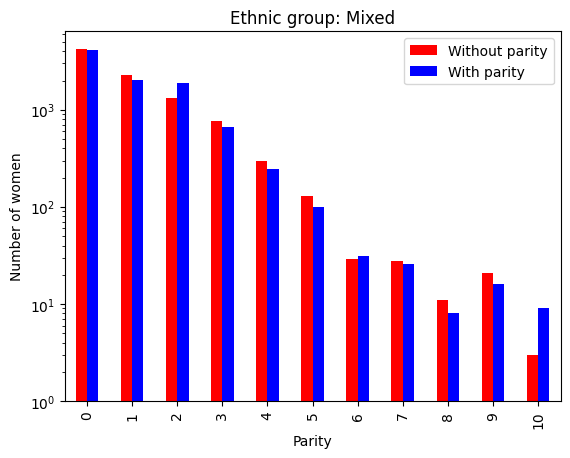

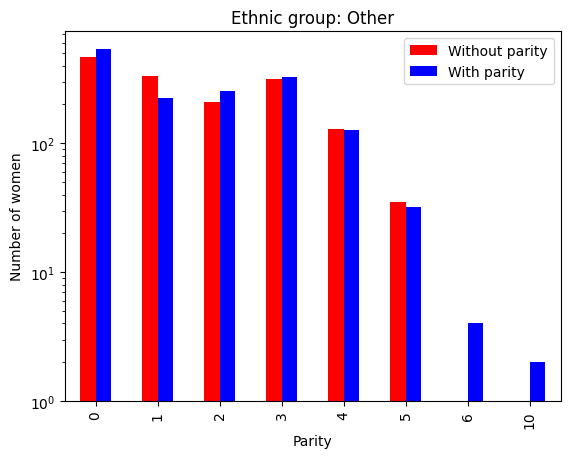

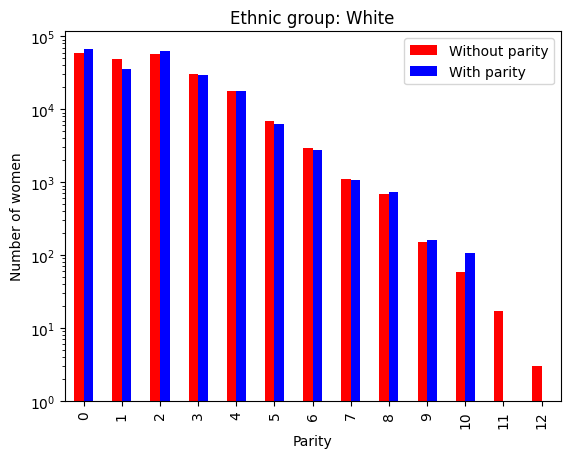

In [14]:
# By ethnic group
apply_ethnicity_group(enddata_p)
apply_ethnicity_group(enddata_np)

for eth in sorted(enddata_p['eth_group'].unique()):
    dp = enddata_p.loc[enddata_p['eth_group'] == eth]
    dnp = enddata_np.loc[enddata_np['eth_group'] == eth]
    
    kp = get_nkids_ind_distribution(dp)
    knp = get_nkids_ind_distribution(dnp)
    kall = pd.DataFrame([knp, kp]).T
    kall.columns = ['Without parity', 'With parity']
    ke = kall.plot.bar(title='Ethnic group: ' + eth.title(), xlabel='Parity', ylabel='Number of women', color=['red', 'blue'], log=True)   

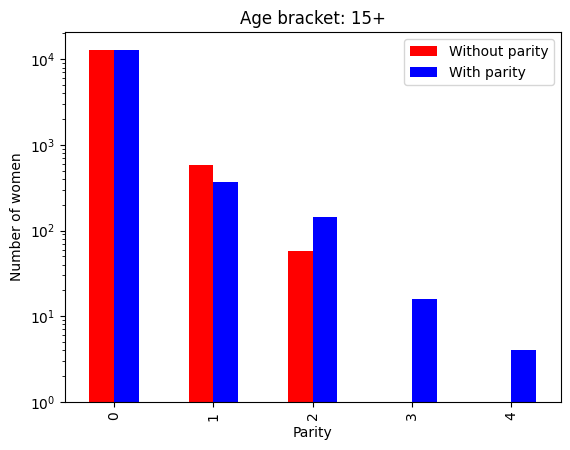

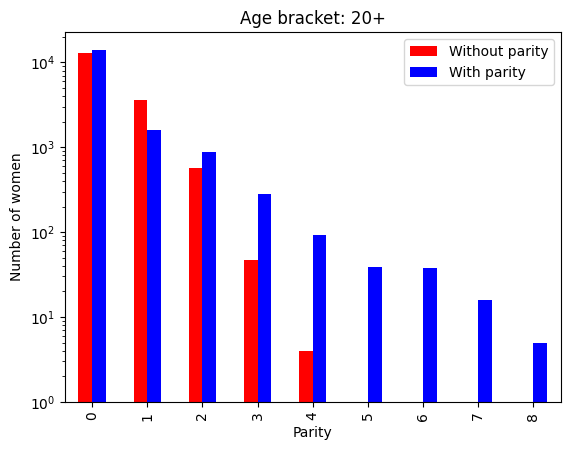

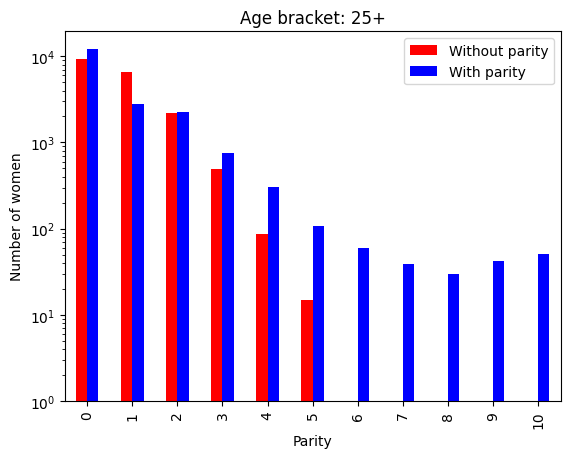

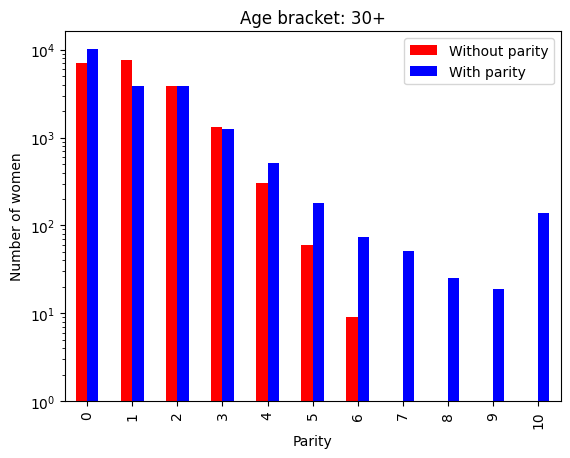

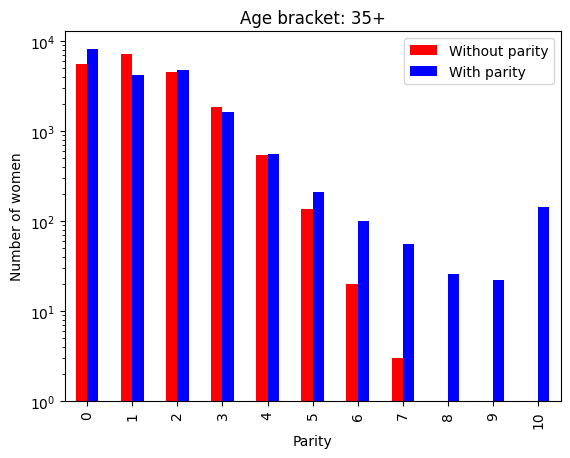

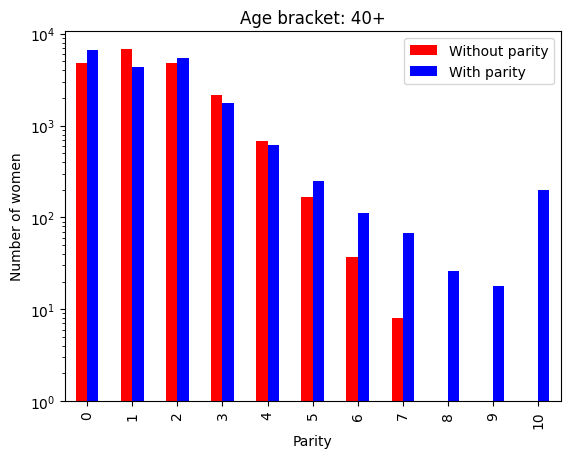

In [15]:
# By age bracket
apply_age_bracket(enddata_p)
apply_age_bracket(enddata_np)

for ab in sorted(enddata_np['age_bracket'].unique().dropna()):
    dp = enddata_p.loc[enddata_p['age_bracket'] == ab]
    dnp = enddata_np.loc[enddata_np['age_bracket'] == ab]
    
    kp = get_nkids_ind_distribution(dp)
    knp = get_nkids_ind_distribution(dnp)
    kall = pd.DataFrame([knp, kp]).T
    kall.columns = ['Without parity', 'With parity']
    ka = kall.plot.bar(title='Age bracket: ' + str(ab) + '+', xlabel='Parity', ylabel='Number of women', color=['red', 'blue'], log=True)